## Redes neuronales recurrentes (RNN)

Las RNN son redes neuronales donde las predicciones pasadas tienen efecto en las predicciones actuales. Son utilizadas para problemas donde existe una componente temporal, por ejemplo, predicción del valor de las acciones o en NLP.
Si bien son muy útiles para estos dominios, son difíciles de entrenar ya que sufren de dos problemas: vanishing gradient y exploding gradient.

**Vanising gradient** ocurre cuando el gradiente tiende a cero, y como resultado no se pueden entrenar los pesos.

**Exploding gradient** es el problema opuesto, donde los gradientes se vuelven muy grandes con lo que la actualización de los pesos diverge.

[Andrew Ng: Vanishing/Exploding gradient](https://www.youtube.com/watch?v=qhXZsFVxGKo)

En esta Notebook veremos dos arquitecturas de RNN utilizadas comunmente en diferentes problemas. Ellas son las RNNs **LSTM** y **GRU**.

***
### Long Short Term Memory (LSTM)

Las LSTM son un tipo especial de red neuronal recurrente utilizada para procesar y predecir secuencias de datos. A diferencia de las RNN tradicionales (RNN Vanilla), las LSTM tienen la capacidad de aprender y recordar a largo plazo las dependencias temporales en los datos de entrada.

Las principales características de las LSTM son:

`a) Memoria a largo plazo`: las LSTM tienen una estructura de memoria interna que les permite recordar información relevante de eventos pasados en una secuencia. Esto es especialmente útil cuando se trabaja con datos que tienen `dependencias a largo plazo.`

La "dependencia a largo plazo" se refiere a la relación entre elementos en una secuencia de datos que están separados por una distancia considerable en términos de posición o tiempo. En otras palabras, implica que la información relevante para tomar decisiones o comprender completamente un evento en una secuencia puede estar distante en el tiempo o la ubicación dentro de la secuencia.

Algunos ejemplos de dependencias a largo plazo:

* Predicción de palabras en una oración: Para comprender plenamente el significado de una palabra en una oración, a menudo es necesario tener en cuenta palabras que aparecen mucho antes en la secuencia. Por ejemplo, en la oración "Vi un tiburón en el océano y me asusté", la palabra "asusté" depende de la presencia de "tiburón" y la experiencia anterior de ver uno en el océano.

* Reconocimiento de voz: En el procesamiento del habla, entender el significado completo de una oración hablada puede requerir considerar palabras o sonidos que ocurrieron mucho tiempo atrás. Por ejemplo, para comprender una pregunta como "¿Cuántos años tienes?", el sistema de reconocimiento de voz debe recordar la primera parte de la pregunta incluso después de escuchar las últimas palabras.

En estos ejemplos, la dependencia a largo plazo implica que la información relevante para tomar decisiones o comprender completamente un elemento en la secuencia se encuentra en eventos pasados que pueden estar distantes temporal o espacialmente. Las LSTM son capaces de capturar y utilizar estas dependencias a largo plazo en su proceso de aprendizaje.

`b) Puertas de información`: las LSTM tienen puertas internas que controlan el flujo de información dentro de la red. Estas puertas ayudan a decidir qué información debe mantenerse, olvidarse o pasar a la siguiente etapa de la red. Las principales puertas en una LSTM son la puerta de entrada (**input gate**), la puerta de olvido (**forget gate**) y la puerta de salida (**output gate**).

`c) Adaptabilidad`: las LSTM pueden aprender automáticamente a través del entrenamiento con datos de secuencias. A medida que se les proporciona más información, pueden ajustar sus parámetros internos y mejorar su capacidad para modelar y predecir patrones en los datos.

Las LSTM se utilizan en una variedad de casos donde se manejan secuencias de datos, como en el procesamiento de texto (análisis de sentimientos, traducción automática), el procesamiento de voz (reconocimiento de voz, síntesis de voz) y la predicción de series temporales (pronóstico del clima, predicción del mercado financiero).

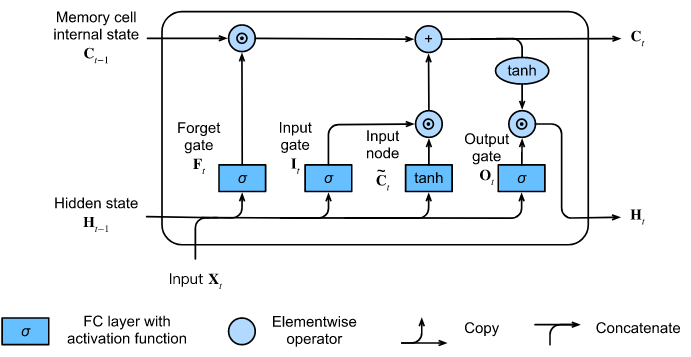

$$f_t= \sigma(W_{f} x_t + U_{f} h_{t-1} + b_f) \\
i_t= \sigma(W_{i} x_t + U_{i} h_{t-1} + b_i) \\
o_t= \sigma(W_{o} x_t + U_{o} h_{t-1} + b_o) \\
\tilde{c}_t = tanh(W_{c} x_t + U_{c} h_{t-1} + b_c) \\
c_t = f_t \circ c_{t-1} + i_t \circ \tilde{c}_t \\
h_t = o_t \circ tanh(c_t)$$

Las LSTM tienen 2 *componentes recurrentes*, el **estado interno de la celda de memoria** $c_{t}$ y su **estado oculto o salida** $h_t$.

El estado interno $c_t$ se calcula como la combinación lineal de $c_{t-1}$ multiplicada (element-wise, `producto Hadamard` o elemento por elemento) por la salida de la **compuerta de olvido** (`forget gate`) $f_t$ y un nuevo $\tilde{c}_t$ multiplicado con la salida de la **compuerta de entrada** (`input gate`) $i_t$.

La salida o estado oculto $h_t$ es igual al producto de la $tanh(c_t)$ y la salida de la **compuerta de salida** (`output gate`) $o_t$.

La utilización de las *compuertas de entrada y olvido* garantiza que los gradientes pasados hacia atrás no se hagan demasiado grandes. Esto se debe a que al utilizar como activación la función sigmoide, los valores están acotados entre 0 y 1.

[Hochreiter, Sepp, and Jürgen Schmidhuber. "Long short-term memory." Neural computation 9.8 (1997): 1735-1780.](http://citeseerx.ist.psu.edu/viewdoc/download?doi=10.1.1.676.4320&rep=rep1&type=pdf)

***
### Gated recurrent unit (GRU)

Las RNN del tipo GRU son utilizadas para procesar y modelar secuencias de datos. Al igual que las LSTM, tienen la capacidad de aprender dependencias temporales en los datos de entrada, pero con una estructura más simplificada.

Las principales características de las GRU son:

`a) Puertas de actualización y reseteo`: Las GRU tienen dos puertas internas, la puerta de actualización (**update gate**) y la puerta de reseteo (**reset gate**). Estas puertas ayudan a controlar cómo se actualiza y se utiliza la información pasada en cada paso de tiempo.

* La puerta de actualización decide qué información se debe actualizar y qué información se debe descartar.

* La puerta de reseteo controla cómo se combina la información pasada con la nueva información de entrada.

`b) Capacidad de retención de información relevante`: Las GRU tienen una estructura interna que les permite retener y actualizar información relevante de eventos pasados en la secuencia. Esto les permite capturar dependencias a largo plazo en los datos, similar a las LSTM, pero con una arquitectura más compacta.

`c) Menor complejidad computacional`: En comparación con las LSTM, las GRU tienen menos componentes y requieren menos operaciones computacionales. Esto puede hacer que las GRU sean más eficientes en términos de tiempo y recursos computacionales, especialmente en conjuntos de datos más pequeños.

Al igual que las LSTM, las GRU se utilizan en diversas aplicaciones que involucran el procesamiento de secuencias de datos. Estos incluyen el procesamiento de lenguaje natural (traducción automática, generación de texto), el análisis de sentimientos, el reconocimiento de voz y la predicción de series temporales.

La GRU procesa secuencialmente los datos de entrada y aprende a modelar patrones en la secuencia. Puede retener información relevante de eventos pasados y utilizarla para hacer predicciones o tomar decisiones en el contexto actual. Esto es especialmente útil en tareas como el procesamiento de lenguaje natural, donde es importante comprender la relación entre las palabras en una oración o texto.

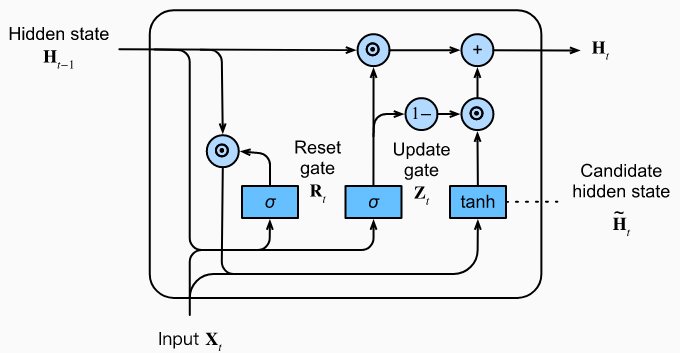

$$r_t = \sigma(W_{r} x_t + U_{r} h_{t-1} + b_r) \\
z_t = \sigma(W_{z} x_t + U_{z} h_{t-1} + b_z) \\
\hat{h}_t = \tanh(W_{h} x_t + U_{h} (r_t \circ h_{t-1}) + b_h) \\
h_t =  (1 - z_t) \circ h_{t-1} + z_t \circ \hat{h}_t
$$

Las GRU solo pasan a la siguiente unidad su salida $h_{t}$. Tienen una `compuerta de actualización` (**update gate**) $z_t$ que estima cual es la importancia de la nueva entrada comparada a la `predicción de la unidad anterior` $h_{t-1}$ para actualizar. Esta update gate calcula un valor entre 0 y 1 (por su función de activación sigmoide).

Por otro lado utilizando $h_{t-1}$ y $x_t$, se calcula una `nueva predicción parcial` $\hat{h}_t$, la cual depende de la entrada actual $x_t$ y de la salida de la unidad anterior $h_{t-1}$.

Finalmente, se arriba a la predicción combinando $h_{t-1}$ y $\hat{h_t}$ linealmente pesando ambos elementos con $(1-z_t)$ y $z_t$ respectivamente.

En el paper original, las GRU se utilizadan para realizar *machine translation*, es decir traducir de un lenguaje.

[Cho, Kyunghyun, et al. "Learning phrase representations using RNN encoder-decoder for statistical machine translation." arXiv preprint arXiv:1406.1078 (2014).](https://arxiv.org/abs/1406.1078)

***
### LSTM y series temporales

A continuación aplicaremos redes recurrentes LSTM al análisis de series temporales.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


Cargamos nuestro dataset (archivo csv) desde Drive usando Pandas.

In [2]:
path = "/content/gdrive/MyDrive/CAECE/U3bis/international-airline-passengers.csv"  #colocar el Path adecuado

df = pd.read_csv(path)
df.columns = ['yyyy-mm', 'Pasajeros']
df.head()

,yyyy-mm,Pasajeros
0,1949-01,112.0
1,1949-02,118.0
2,1949-03,132.0
3,1949-04,129.0
4,1949-05,121.0


In [3]:
#tamaño del DataFrame
print(f'Tamaño del dataset: {df.shape}')
df.tail(5) #visualizamos las últimas 5 filas del DataFrame

Tamaño del dataset: (145, 2)


,yyyy-mm,Pasajeros
140,1960-09,508.0
141,1960-10,461.0
142,1960-11,390.0
143,1960-12,432.0
144,International airline passengers: monthly tota...,NaN


In [4]:
#eliminamos la última fila
df = df.iloc[:-1]
df.tail(5)

,yyyy-mm,Pasajeros
139,1960-08,606.0
140,1960-09,508.0
141,1960-10,461.0
142,1960-11,390.0
143,1960-12,432.0


A continuación graficamos los datos (serie temporal)

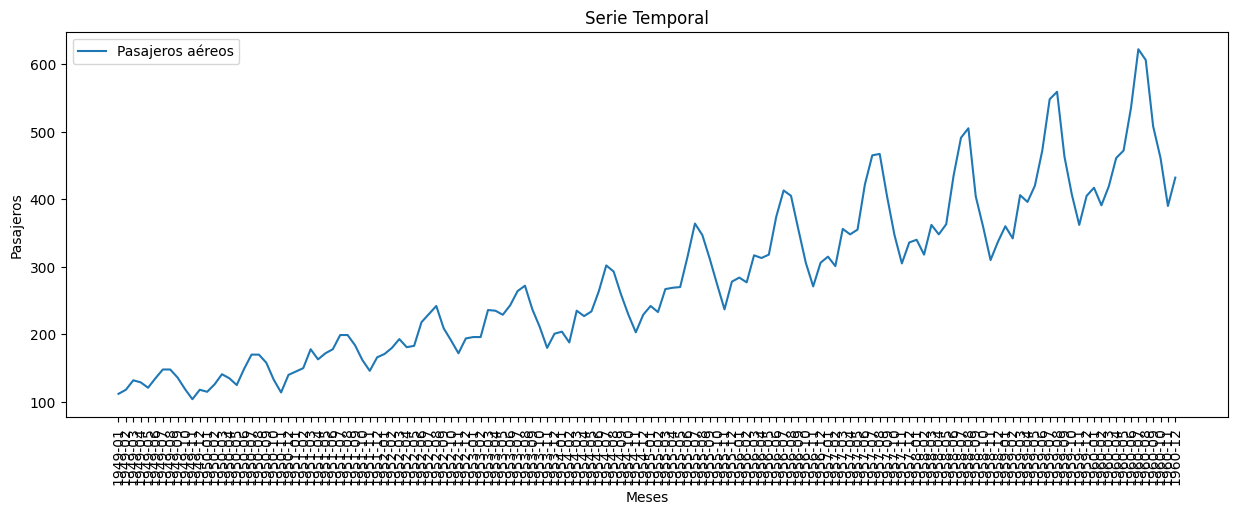

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(df['yyyy-mm'], df['Pasajeros'], label="Pasajeros aéreos")
plt.title('Serie Temporal')
plt.xlabel("Meses")
plt.ylabel("Pasajeros")
plt.xticks(rotation = 90) #roto las etiquetas
plt.legend()

`Nota`: se observa una **tendencia** creciente en los datos de la serie temporal. Se incrementa el número de pasajeros a medida que pasan los años y hay una evidente estructura temporal que se repite periódicamente (mínimos y máximos en cada período de tiempo)

A continuación escalaremos los datos de la serie para alimentar la red. A cada dato le restamos el mínimo del dataset y lo dividimos por el rango (máximo-mínimo).

In [5]:
# Escalamos los datos al intervalo [0,1]
# Para no "perder" la variable Pasajeros, definimos una nueva variable (Pasajeros_escalados)
df['Pasajeros_escalados'] = (df['Pasajeros'] - df['Pasajeros'].min()) / (df['Pasajeros'].max() - df['Pasajeros'].min())
df.head()

,yyyy-mm,Pasajeros,Pasajeros_escalados
0,1949-01,112.0,0.015444
1,1949-02,118.0,0.027027
2,1949-03,132.0,0.054054
3,1949-04,129.0,0.048263
4,1949-05,121.0,0.032819


In [6]:
#Dataset completo: 12 años de datos, con datos mensuales
#Separamos el dataset en training y testing:
train = df[df['yyyy-mm'] <= '1957-12']  #9 años de datos
test  = df[df['yyyy-mm'] >= '1958-01']  #3 años de datos
train.shape, test.shape

((108, 3), (36, 3))

De la serie temporal tomamos los primeros 9 años para entrenar nuestro modelo LSTM, y luego compararemos los restantes 3 años de datos con las predicciones generadas por la red recurrente.

In [17]:
#Trabajamos con la variable escalada
ws = 1 #ws (windows size): tomamos ventana de un mes, pueden probar con otro valor (homework)

X_train = pd.concat([train['Pasajeros_escalados'].shift(w, fill_value=0) for w in range(1, ws+1)], axis=1, keys=[f"Pasajeros_escalados{w}" for w in range(1, ws+1)])
y_train = train['Pasajeros_escalados']

X_test  = pd.concat([test['Pasajeros_escalados'].shift(w, fill_value=0) for w in range(1, ws+1)], axis=1, keys=[f"Pasajeros_escalados{w}" for w in range(1, ws+1)])
y_test  = test['Pasajeros_escalados']

`Notas`:

**pd.concat()**: función de Pandas que concatena objetos a lo largo de un eje en particular. En este caso se utiliza para concatenar las columnas generadas a partir de la columna "Pasajeros_escalados" desplazada.

**[train['Pasajeros_escalados'].shift(w, fill_value=0) for w in range(1, window_size+1)]**: comprensión de lista que genera una lista de columnas desplazadas a partir de la columna "Pasajeros_escalados" en el DataFrame train.

**shift()** se utiliza para desplazar los valores hacia abajo en la columna. La cantidad de desplazamiento es controlada por el parámetro **w**, que varía en el rango de 1 a ws+1.

**fill_value=0** se utiliza para rellenar los valores faltantes en las filas desplazadas con ceros. La función shift es muy útil cuando trabajamos con datos tipo `series temporales`.

**axis=1**: especifica que la concatenación se realizará a lo largo del eje de las columnas.

**keys=[f"Pasajeros_escalados{w}" for w in range(1, window_size+1)]**: asigna nombres a las columnas generadas.

In [18]:
#Estamos tomando solo el mes anterior
print(X_train[:7])
print('\n------------\n')
print(y_train[:7])

   Pasajeros_escalados1
0              0.000000
1              0.015444
2              0.027027
3              0.054054
4              0.048263
5              0.032819
6              0.059846

------------

0    0.015444
1    0.027027
2    0.054054
3    0.048263
4    0.032819
5    0.059846
6    0.084942
Name: Pasajeros_escalados, dtype: float64


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 4)                 96        
                                                                 
 dense (Dense)               (None, 1)                 5         
                                                                 
Total params: 101
Trainable params: 101
Non-trainable params: 0
_________________________________________________________________


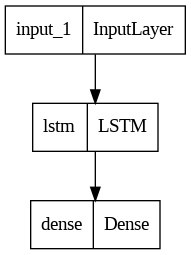

In [19]:
 #Definimos la arquitectura de la red
from keras.models import Sequential
from keras.layers import Input, LSTM, GRU, Dense
from keras.utils import plot_model

# start from scratch
keras.backend.clear_session()

model1 = Sequential([
    Input(shape=[1, ws]), #capa de entrada : entra 1 dato con información de 1 mes
    LSTM(4),    #4: indica cuanto quiero que recuerde hacia atrás
    Dense(1),   #salida: solo quiero predecir un valor
 ])

model1.summary()
plot_model(model1)

`NOTAS`:

**keras.layers.Input(shape=[1, ws])**: capa de entrada del modelo. Especifica la forma de entrada de los datos al modelo. En este caso, los datos de entrada deben tener una forma de (1, ws). Esto es común en el procesamiento de series temporales, donde el dato de entrada es una secuencia de longitud ws.

**keras.layers.LSTM(4)**: capa LSTM en el modelo, tiene 4 unidades (o nodos), lo que significa que tiene 4 conjuntos de celdas de memoria para recordar información a largo plazo en los datos de entrada. La capa LSTM se utiliza para capturar las dependencias temporales en los datos secuenciales y extraer características relevantes.

**keras.layers.Dense(1)**: capa de salida del modelo, es una capa densa (FC) que produce una salida unidimensional. En este caso, se utiliza para predecir un solo valor de salida.

Este modelo se puede utilizar para problemas de predicción de series temporales donde se busca predecir un valor basado en una secuencia de datos previos.

In [20]:
#Compilamos y ejecutamos
model1.compile(loss="mean_squared_error", optimizer="adam", metrics="mean_squared_error")
model1.fit(X_train, y_train, epochs=100, batch_size=1, verbose=True)

Epoch 1/100
108/108 [==============================] - 8s 4ms/step - loss: 0.0329 - mean_squared_error: 0.0329
Epoch 2/100
108/108 [==============================] - 0s 4ms/step - loss: 0.0154 - mean_squared_error: 0.0154
Epoch 3/100
108/108 [==============================] - 0s 4ms/step - loss: 0.0126 - mean_squared_error: 0.0126
Epoch 4/100
108/108 [==============================] - 0s 4ms/step - loss: 0.0110 - mean_squared_error: 0.0110
Epoch 5/100
108/108 [==============================] - 0s 4ms/step - loss: 0.0096 - mean_squared_error: 0.0096
Epoch 6/100
108/108 [==============================] - 0s 4ms/step - loss: 0.0083 - mean_squared_error: 0.0083
Epoch 7/100
108/108 [==============================] - 0s 4ms/step - loss: 0.0070 - mean_squared_error: 0.0070
Epoch 8/100
108/108 [==============================] - 0s 4ms/step - loss: 0.0059 - mean_squared_error: 0.0059
Epoch 9/100
108/108 [==============================] - 0s 3ms/step - loss: 0.0050 - mean_squared_error: 0.0050
E

In [21]:
#calculamos la predicción del modelo1 utilizando los datos de testing
y_pred = model1.predict(X_test)
print(f'y_pred.shape: {y_pred.shape}')
print(f'y_test.shape: {y_test.shape}')

#Para calcular el error (RMSE) tanto y_pred como y_test deben ser ndarray 1D
#Cómo y_pred no lo es, debo reshapearlo aplicando flatten
y_pred = y_pred.flatten()
print(f'y_pred 1D: {y_pred.shape}')

2/2 [==============================] - 1s 7ms/step
y_pred.shape: (36, 1)
y_test.shape: (36,)
y_pred 1D: (36,)


In [22]:
# Calculamos la métrica RMSE (raiz cuadrada del error cuadrático medio)
rmse = np.sqrt(np.mean((y_pred - y_test)**2))
print(f'RMSE con datos de testing: {rmse}')

RMSE con datos de testing: 0.11818768502348716


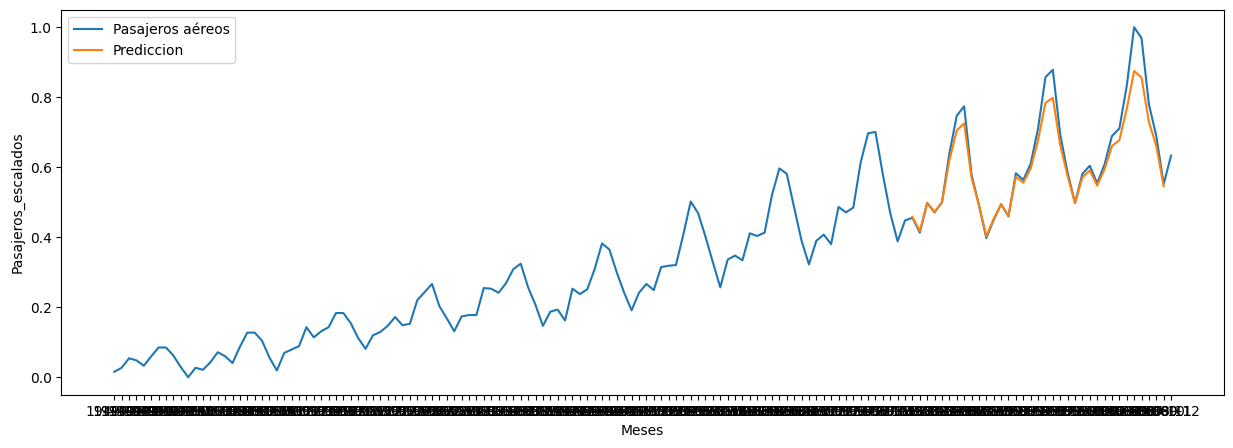

In [ ]:
#Grafico con la variable escalada
plt.figure(figsize=(15, 5))
plt.plot(df['yyyy-mm'], df['Pasajeros_escalados'], label="Pasajeros aéreos")
plt.plot(test['yyyy-mm'][:-ws], y_pred[ws:], label="Prediccion")
plt.xlabel("Meses")
plt.ylabel("Pasajeros_escalados")
plt.legend()
plt.show()

NOTA: Vemos que el ajuste es muy bueno (la predicción del modelo se acerca mucho a la verdad) salvo en los picos, que no los está aprendiendo correctamente.

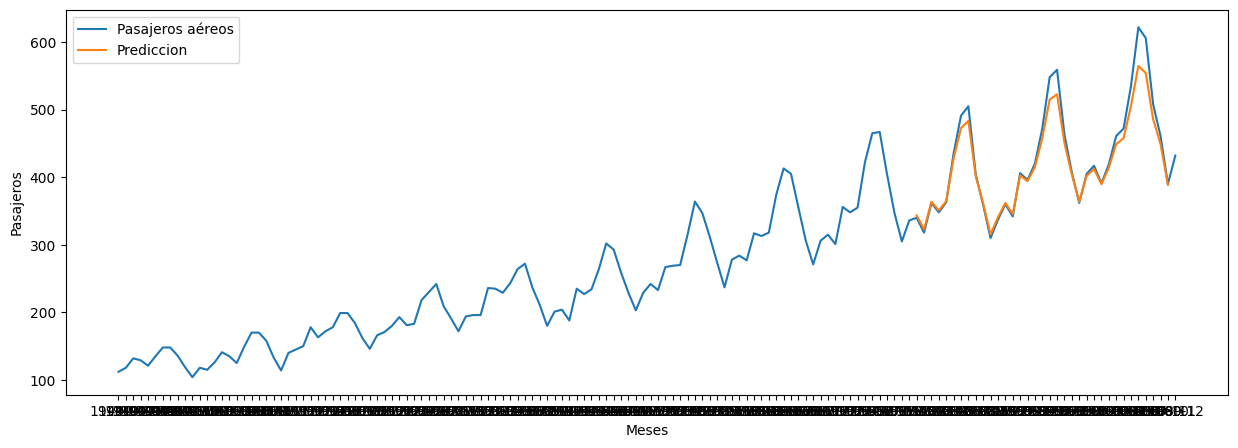

In [23]:
#Para graficar con las unidades originales (no escaladas) debo hacer una conversión:
#df['Pasajeros_escalados'] = (df['Pasajeros'] - df['Pasajeros'].min()) / (df['Pasajeros'].max() - df['Pasajeros'].min())  # Escalamos
y_pred_orig = y_pred*(df['Pasajeros'].max() - df['Pasajeros'].min())+df['Pasajeros'].min()

#Observamos el mismo gráfico, con escala diferente en el eje y.
plt.figure(figsize=(15, 5))
plt.plot(df['yyyy-mm'], df['Pasajeros'], label="Pasajeros aéreos")
plt.plot(test['yyyy-mm'][:-ws], y_pred_orig[ws:], label="Prediccion") #Usamos y_pred_orig
plt.xlabel("Meses")
plt.ylabel("Pasajeros")
plt.legend()

Observar que la LSTM no hace la predicción (curva naranja) del último dato de la serie (curva azul).

In [ ]:
#Para guardar las predicciones
#Inspeccionamos con test
print(f'test.shape: {test.shape}')
test.head()

test.shape: (36, 3)


,yyyy-mm,Pasajeros,Pasajeros_escalados
108,1958-01,340.0,0.455598
109,1958-02,318.0,0.413127
110,1958-03,362.0,0.498069
111,1958-04,348.0,0.471042
112,1958-05,363.0,0.500000


In [25]:
X_test[:5]

,Pasajeros_escalados1
108,0.000000
109,0.455598
110,0.413127
111,0.498069
112,0.471042


In [26]:
y_pred_orig[:5]

array([115.958954, 343.5119  , 322.8946  , 363.74106 , 350.9154  ],
      dtype=float32)

In [27]:
#Para poder unirlo al DataFrame test, tenemos que convertir y_pred_orig en un DataFrame
pred_orig_df=pd.DataFrame(y_pred_orig[1:36]) #como el primer lugar de X_test está en 0, el primer predicho "real" está en el segundo lugar
pred_orig_df.columns = ['Predichos'] #le ponemos nombre a la columna

print(f'pred_orig_df.shape: {pred_orig_df.shape}')
pred_orig_df.head()

pred_orig_df.shape: (35, 1)


,Predichos
0,343.511902
1,322.894592
2,363.741058
3,350.915405
4,364.650543


In [31]:
print(f'test.shape: {test.shape}')
test.head()

test.shape: (36, 3)


,yyyy-mm,Pasajeros,Pasajeros_escalados
108,1958-01,340.0,0.455598
109,1958-02,318.0,0.413127
110,1958-03,362.0,0.498069
111,1958-04,348.0,0.471042
112,1958-05,363.0,0.500000


In [32]:
#creamos un índice para que tanto pred_orig_df como test tengan el mismo índice
test.index = range(test.shape[0])
test.index

RangeIndex(start=0, stop=36, step=1)

Observación: el DataFrame test tiene una fila más que pred_orig_df. Por lo tanto, eliminamos la última fila de test para poder unir ambos DataFrame

In [33]:
test35 = test.iloc[:-1] #eliminamos la última fila

print(f'test35.shape: {test35.shape}')
test35[:5]

test35.shape: (35, 3)


,yyyy-mm,Pasajeros,Pasajeros_escalados
0,1958-01,340.0,0.455598
1,1958-02,318.0,0.413127
2,1958-03,362.0,0.498069
3,1958-04,348.0,0.471042
4,1958-05,363.0,0.500000


In [35]:
#Creamos un nuevo DataFrame
predichos_testing = pd.concat([test35, pred_orig_df] ,axis=1) #indico uno al lado de otro
predichos_testing.head()

#Lo guardamos como csv
predichos_testing.to_csv('Predichos_testing.csv')
#Donde lo guarda???

***
**Ejercicios** : Replicar el gráfico en las unidades originales para las otras arquitecturas:

In [48]:
# start from scratch
keras.backend.clear_session()

model2 = Sequential([
    Input(shape=[1, ws]), # entra 1 dato con información de 1 mes
    LSTM(4),
    Dense(ws), # opcional
    Dense(1),   #solo quiero predecir un valor
 ])

model2.compile(loss="mean_squared_error", optimizer="adam", metrics="mean_squared_error")
history = model2.fit(X_train, y_train, epochs=100, batch_size=1, verbose=True)

Epoch 1/100
108/108 [==============================] - 2s 4ms/step - loss: 0.0478 - mean_squared_error: 0.0478
Epoch 2/100
108/108 [==============================] - 0s 4ms/step - loss: 0.0231 - mean_squared_error: 0.0231
Epoch 3/100
108/108 [==============================] - 0s 4ms/step - loss: 0.0203 - mean_squared_error: 0.0203
Epoch 4/100
108/108 [==============================] - 0s 4ms/step - loss: 0.0183 - mean_squared_error: 0.0183
Epoch 5/100
108/108 [==============================] - 0s 4ms/step - loss: 0.0162 - mean_squared_error: 0.0162
Epoch 6/100
108/108 [==============================] - 0s 4ms/step - loss: 0.0143 - mean_squared_error: 0.0143
Epoch 7/100
108/108 [==============================] - 0s 4ms/step - loss: 0.0121 - mean_squared_error: 0.0121
Epoch 8/100
108/108 [==============================] - 0s 4ms/step - loss: 0.0101 - mean_squared_error: 0.0101
Epoch 9/100
108/108 [==============================] - 0s 4ms/step - loss: 0.0080 - mean_squared_error: 0.0080
E

2/2 [==============================] - 1s 10ms/step
RMSE datos de testing modelo 2: 0.12230308226224768


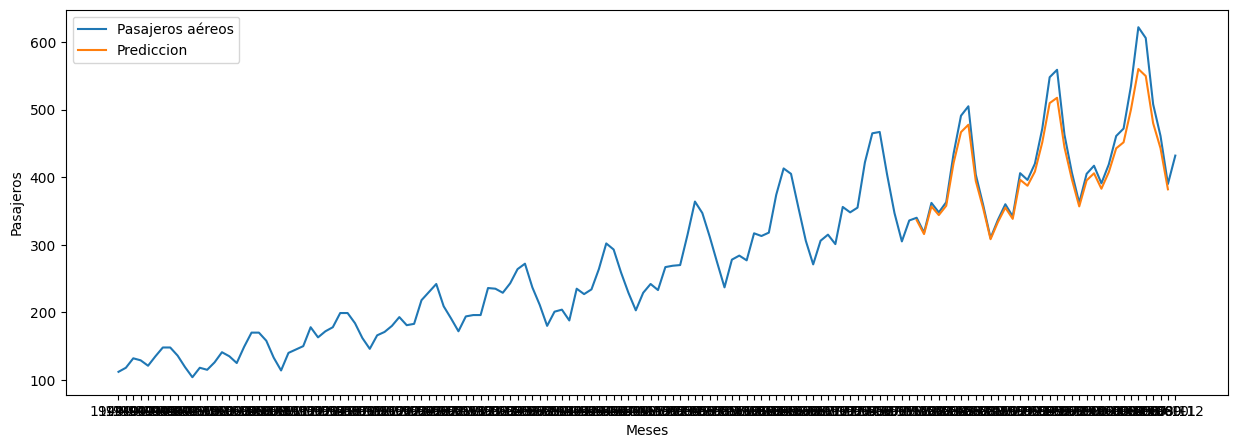

In [49]:
y_pred2 = model2.predict(X_test)
y_pred2 = y_pred2.flatten()
rmse = np.sqrt(np.mean((y_pred2 - y_test)**2))
print(f'RMSE datos de testing modelo 2: {rmse}')

pred2_orig=y_pred2*(df['Pasajeros'].max() - df['Pasajeros'].min())+df['Pasajeros'].min()

plt.figure(figsize=(15, 5))
plt.plot(df['yyyy-mm'], df['Pasajeros'], label="Pasajeros aéreos")
plt.plot(test['yyyy-mm'][:-ws], pred2_orig[ws:], label="Prediccion")
plt.xlabel("Meses")
plt.ylabel("Pasajeros")
plt.legend()

Podemos observar que al agregar una capa FC adicional no mejoró el resultado, al contrario, lo empeoró.

In [50]:
# start from scratch
keras.backend.clear_session()

#Modelo 3: 12 celdas LSTM
model3 = Sequential([
    Input(shape=[1, ws]), # entra 1 dato con información de 1 mes
    LSTM(12),
    Dense(1), # opcional
    Dense(1), #solo quiero predecir un valor
 ])

model3.compile(loss="mean_squared_error", optimizer="adam", metrics="mean_squared_error")
history = model3.fit(X_train, y_train, epochs=100, batch_size=1, verbose=True)

Epoch 1/100
108/108 [==============================] - 3s 4ms/step - loss: 0.0609 - mean_squared_error: 0.0609
Epoch 2/100
108/108 [==============================] - 0s 4ms/step - loss: 0.0274 - mean_squared_error: 0.0274
Epoch 3/100
108/108 [==============================] - 0s 4ms/step - loss: 0.0208 - mean_squared_error: 0.0208
Epoch 4/100
108/108 [==============================] - 0s 4ms/step - loss: 0.0188 - mean_squared_error: 0.0188
Epoch 5/100
108/108 [==============================] - 0s 4ms/step - loss: 0.0165 - mean_squared_error: 0.0165
Epoch 6/100
108/108 [==============================] - 0s 4ms/step - loss: 0.0142 - mean_squared_error: 0.0142
Epoch 7/100
108/108 [==============================] - 0s 4ms/step - loss: 0.0120 - mean_squared_error: 0.0120
Epoch 8/100
108/108 [==============================] - 0s 4ms/step - loss: 0.0096 - mean_squared_error: 0.0096
Epoch 9/100
108/108 [==============================] - 0s 4ms/step - loss: 0.0074 - mean_squared_error: 0.0074
E

In [51]:
y_pred3 = model3.predict(X_test)
y_pred3 = y_pred3.flatten()
rmse = np.sqrt(np.mean((y_pred3 - y_test)**2))
print(f'RMSE modelo 3: {rmse}')
pred3_orig=y_pred3*(df['Pasajeros'].max() - df['Pasajeros'].min())+df['Pasajeros'].min()


2/2 [==============================] - 1s 5ms/step
RMSE modelo 3: 0.12152600142062146


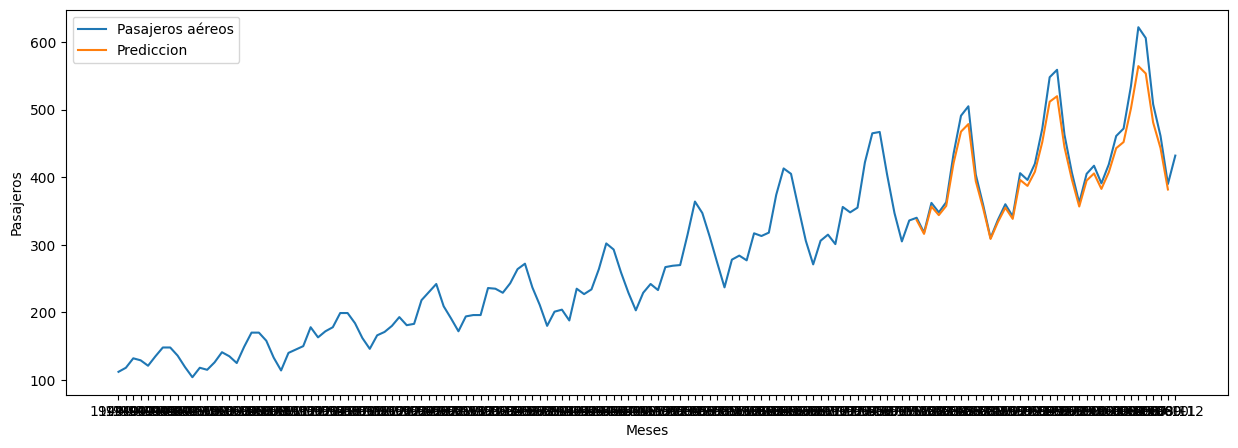

In [52]:
plt.figure(figsize=(15, 5))
plt.plot(df['yyyy-mm'], df['Pasajeros'], label="Pasajeros aéreos")
plt.plot(test['yyyy-mm'][:-ws], pred3_orig[ws:], label="Prediccion")
plt.xlabel("Meses")
plt.ylabel("Pasajeros")
plt.legend()
plt.show()

Nuevamente observamos que el modelo 3 tiene una peor performance que el modelo 1.

***
Ahora utilizaremos una RNN del tipo GRU

In [53]:
# start from scratch
keras.backend.clear_session()

model4 = Sequential([
    Input(shape=[1, ws]), # entra 1 dato con información de 1 mes
    GRU(4),
    Dense(ws), # opcional
    Dense(1),  # solo quiero predecir un valor
 ])

model4.compile(loss="mean_squared_error", optimizer="adam", metrics="mean_squared_error")
history = model4.fit(X_train, y_train, epochs=100, batch_size=1, verbose=True)

Epoch 1/100
108/108 [==============================] - 2s 4ms/step - loss: 0.0123 - mean_squared_error: 0.0123
Epoch 2/100
108/108 [==============================] - 0s 4ms/step - loss: 0.0063 - mean_squared_error: 0.0063
Epoch 3/100
108/108 [==============================] - 0s 4ms/step - loss: 0.0045 - mean_squared_error: 0.0045
Epoch 4/100
108/108 [==============================] - 0s 4ms/step - loss: 0.0036 - mean_squared_error: 0.0036
Epoch 5/100
108/108 [==============================] - 0s 4ms/step - loss: 0.0030 - mean_squared_error: 0.0030
Epoch 6/100
108/108 [==============================] - 0s 4ms/step - loss: 0.0027 - mean_squared_error: 0.0027
Epoch 7/100
108/108 [==============================] - 0s 4ms/step - loss: 0.0026 - mean_squared_error: 0.0026
Epoch 8/100
108/108 [==============================] - 0s 4ms/step - loss: 0.0025 - mean_squared_error: 0.0025
Epoch 9/100
108/108 [==============================] - 0s 4ms/step - loss: 0.0026 - mean_squared_error: 0.0026
E

In [54]:
y_pred4 = model4.predict(X_test)
y_pred4 = y_pred4.flatten()
rmse = np.sqrt(np.mean((y_pred4 - y_test)**2))
print(f'RMSE modelo 4: {rmse}')
pred4_orig=y_pred4*(df['Pasajeros'].max() - df['Pasajeros'].min())+df['Pasajeros'].min()


2/2 [==============================] - 0s 5ms/step
RMSE modelo 4: 0.1175692084163739


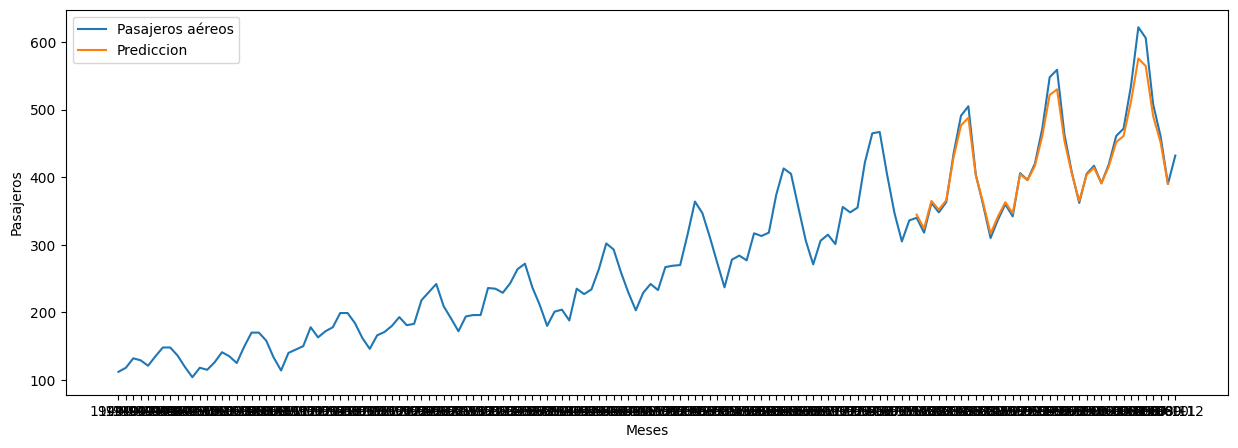

In [55]:
plt.figure(figsize=(15, 5))
plt.plot(df['yyyy-mm'], df['Pasajeros'], label="Pasajeros aéreos")
plt.plot(test['yyyy-mm'][:-ws], pred4_orig[ws:], label="Prediccion")
plt.xlabel("Meses")
plt.ylabel("Pasajeros")
plt.legend()
plt.show()

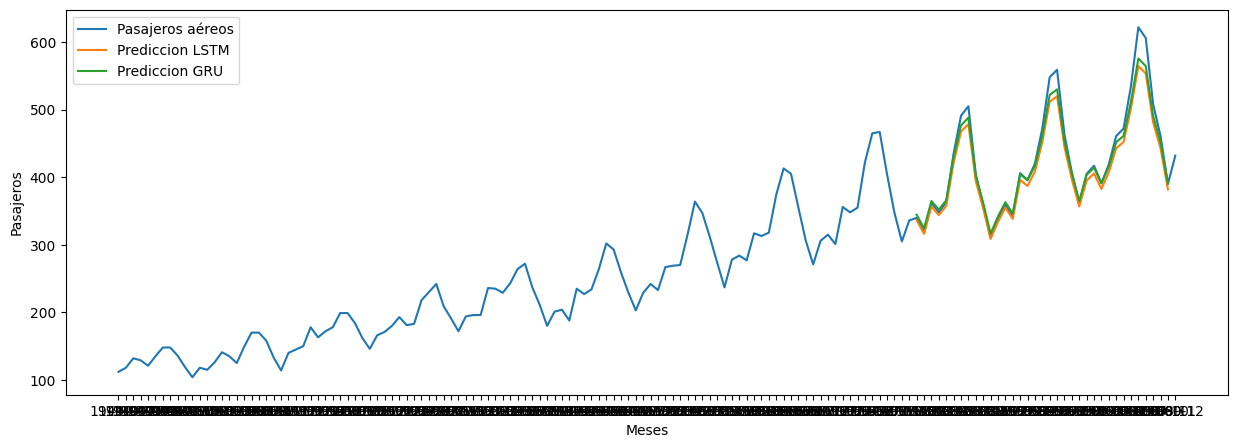

In [56]:
#Comparamos LSTM (modelo 3) con GRU (modelo 4)
plt.figure(figsize=(15, 5))
plt.plot(df['yyyy-mm'], df['Pasajeros'], label="Pasajeros aéreos")
plt.plot(test['yyyy-mm'][:-ws], pred3_orig[ws:], label="Prediccion LSTM")
plt.plot(test['yyyy-mm'][:-ws], pred4_orig[ws:], label="Prediccion GRU")
plt.xlabel("Meses")
plt.ylabel("Pasajeros")
plt.legend()